# False positives

In [ ]:
# To import seaborn, we need to pip install it first. 
# Run this cell and restart the kernel before continuing
# (circle with arrow symbol on the top bar)
!pip install --no-index seaborn

In [1]:
# In case of problems with importing libraries
# Go to "Softwares" (blue cube symbol on the left)
# Load the python/3.9.6 ipython-kernel/3.9 modules
# Load scipy-stack/2023a StdEnv/2020 gcc/9.3.0 root/6.26.06
# then select the Python 3.9 kernel on the top right
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from seaborn import heatmap
from pathlib import Path
from itertools import product

In [2]:
import subprocess
from os import listdir
import pandas as pd
from tabulate import tabulate
remove_NaN = lambda row : row[np.isfinite(row)]

In [15]:
from workspace import Workspace
from scipy import stats

def gaussian(x, mean, width):
    """
    Creates a normal (area 1) Gaussian with a given mean and width
    mean - bin number
    width - number of bins
    """
    return stats.norm.pdf(x, loc=mean, scale=width)

def poisson(x, mean, mu):
    """
    """
    return stats.poisson.pmf(x, mu, loc=mean)

In [16]:
# Get smoothed histogram
from scipy.optimize import curve_fit
def smooth(h, verbose=False):

    # Remove zeros
    zeros = np.where(h == 0)[0]
    if len(zeros) > 0:
        h = h[:zeros[0]]
   
    # Get binning with bin numbers
    n_bin_edges = np.linspace(1, len(h), num=len(h)+1)
    n_bin_centers = (n_bin_edges[1:] + n_bin_edges[:-1]) / 2
    if verbose:
        print('Number edges', len(n_bin_edges), n_bin_edges[:3], n_bin_edges[-3:])
        print('Number centers', len(n_bin_centers), n_bin_centers[:3], n_bin_centers[-3:])

     # Define the ln function for the fit
    def ln(x, p0, p1, p2, p3, p4):
        return p0 + p1*x + p2*x**2 + p3*x**3 +p4*x**4

    # Fit ln function using bin numbers
    yerr = np.sqrt(h)
    ln_yerr = 1/yerr
    x = np.arange(len(h)) # Should be bin centers?
    popt, pcov = curve_fit(ln, x , np.log(h), sigma=ln_yerr)
    bkg = np.exp(ln(x, *popt))#.astype(int)

    # Calculate goodness-of-fit
    ndof = len(h) - 1
    chi2 = np.sum((h-bkg)**2/yerr**2)/ndof
    if verbose:
        print(f'chi2/ndof = {np.sum((h-bkg)**2/yerr**2)}/{ndof} = {chi2}')
    
    return bkg, chi2


## Get false positives

In [3]:
# Load data
data = {}
dfs = {}
for tag in [1,2,3,4]:

    data[tag] = {}

    bkg_sample = f'input_analysis10_eva_background_chan3_8.02'
    bkg_prediction = f'prediction_Znet3_DMfunc_{tag}_width_sig_on_background_chan3_8.02_eva'
    
    for file in ['X', 'M', 'C']:
        csv_file = f'{bkg_sample}/{file}.csv'
        df = pd.read_csv(csv_file, header=None)
        if file == 'C':
            data[tag][file] = np.array([row[0] for row in df.to_numpy()], dtype=str)
        else:
            data[tag][file] = np.array([remove_NaN(row) for row in df.to_numpy().astype('float')], dtype=object)
    
        
    zpred_file = f'{bkg_prediction}/pred_z.npy'
    bpred_file = f'{bkg_prediction}/pred_b.npy'

    data[tag]['zpred'] = np.load(zpred_file, allow_pickle=True)
    data[tag]['bpred'] = np.load(bpred_file, allow_pickle=True)

    zmax = np.array([np.nanmax(row) for row in data[tag]['zpred']])
    mass = np.array([data[tag]['M'][i][np.argmax(row)] for i,row in enumerate(data[tag]['zpred'])])
    zmax_bin = np.array([np.argmax(row) for row in data[tag]['zpred']])

    nbins = np.array([row.shape[0] for row in data[tag]['X']])
    ymin = np.array([np.nanmin(row) for row in data[tag]['X']])
    ymax = np.array([np.nanmax(row) for row in data[tag]['X']])
    xmin = np.array([np.nanmin(row) for row in data[tag]['M']])
    xmax = np.array([np.nanmax(row) for row in data[tag]['M']])

    columns = ['name', 'zmax', 'mass', 'zmax_bin', 'nbins', 'ymin', 'ymax', 'xmin', 'xmax']
    df_data = np.array([data[tag]['C'], zmax, mass, zmax_bin, nbins, ymin, ymax, xmin, xmax]).T
    df = pd.DataFrame(data=df_data, columns=columns)
    for col in columns:
        if col == 'name': continue
        df[col] = pd.to_numeric(df[col])
      
    get_signature = lambda row : row['name'].split('__')[0] if '__' in row['name'] else row['name']
    get_observable = lambda row : row['name'].split('__')[1] if '__' in row['name'] else row['name']
    df['sig'] = df.apply(get_signature, axis=1)
    df['obs'] = df.apply(get_observable, axis=1)
    
    dfs[tag] = df

print(data[1]['X'].shape, dfs[1].shape, np.unique(data[1]['C']).shape)
dfs[1].head()
# dfs[1].loc[:,['name', 'sig', 'obs']].tail()

(33120,) (33120, 11) (33059,)


,name,zmax,mass,zmax_bin,nbins,ymin,ymax,xmin,xmax,sig,obs
0,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10ex__j0.j1_...,1.568558,1678.0,39,94,0.0,96.0,709.0,3707.0,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10ex,j0.j1_mass
1,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10ex__j0.j1_...,2.294669,3059.0,27,35,0.0,172.0,1000.0,3882.0,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10ex,j0.j1_massT
2,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10ex__j0.j1_...,2.106121,3109.0,27,34,0.0,179.0,1028.0,3828.0,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10ex,j0.j1_massMET
3,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10ex__j0.j2_...,1.495878,2094.0,71,116,0.0,113.0,381.0,3848.0,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10ex,j0.j2_mass
4,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10ex__j0.j3_...,2.071802,1857.0,65,92,0.0,132.0,361.0,2797.0,hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_10ex,j0.j3_mass


In [5]:
# Print statistics
final_states = np.unique([h.split('__') for h in dfs[1]["name"]])
print(f'{dfs[1]["name"].shape[0]} histograms ({dfs[1]["name"].unique().shape[0]} unique ones)\n'
      f'  {final_states.shape[0]} final states\n'
      f'  {dfs[1]["nbins"].min()} <= Nbins <= {dfs[1]["nbins"].max()}\n'
      f'  {dfs[1]["ymin"].min()} <= entries per bin <= {dfs[1]["ymax"].max()}\n'
      f'  {dfs[1]["xmin"].min()} <= mass <= {dfs[1]["xmax"].max()}'
      )

33120 histograms (33059 unique ones)
  2297 final states
  31 <= Nbins <= 184
  0.0 <= entries per bin <= 163996.0
  48.0 <= mass <= 9150.0


In [6]:
def get_obs(obs):
    if 'massT' in obs: return 'massT'
    elif 'massMET' in obs: return 'massMET'
    else: return 'mass'

# massT = np.array([h for i,h in enumerate(dfs[1]["name"]) if 'massT' in h])
# massMET = np.array([h for i,h in enumerate(dfs[1]["name"]) if 'massMET' in h])
# mass = np.array([h for i,h in enumerate(dfs[1]["name"]) if not 'massT' in h and not 'massMET' in h])

table_data = [
    ['', 'Histograms', 'Unique'],
    ['Total', f'{dfs[1].shape[0]}', f'{dfs[1]["name"].unique().shape[0]}'],
    ['massT', 
        f'{dfs[1][dfs[1]["name"].apply(get_obs) == "massT"]["name"].shape[0]}', 
        f'{dfs[1][dfs[1]["name"].apply(get_obs) == "massT"]["name"].unique().shape[0]}'
    ],
    ['massMET', 
        f'{dfs[1][dfs[1]["name"].apply(get_obs) == "massMET"]["name"].shape[0]}', 
        f'{dfs[1][dfs[1]["name"].apply(get_obs) == "massMET"]["name"].unique().shape[0]}'
    ],
    ['mass', 
        f'{dfs[1][dfs[1]["name"].apply(get_obs) == "mass"]["name"].shape[0]}', 
        f'{dfs[1][dfs[1]["name"].apply(get_obs) == "mass"]["name"].unique().shape[0]}'
    ]]
print(tabulate(table_data, headers='firstrow',
               tablefmt='rounded_outline', floatfmt=".4g"))



╭─────────┬──────────────┬──────────╮
│         │   Histograms │   Unique │
├─────────┼──────────────┼──────────┤
│ Total   │        33120 │    33059 │
│ massT   │         5934 │     5920 │
│ massMET │         5854 │     5843 │
│ mass    │        21332 │    21296 │
╰─────────┴──────────────┴──────────╯


In [7]:
# Get false positives
table_data = [['', 'zmax ≥ 3', 'zmax ≥ 4', 'zmax ≥ 5', 'zmax ≥ 6', 'zmax ≥ 7']]

false_positives = {}
for tag in [1,2,3,4]:
    
    df = dfs[tag]
    tot = df['name'].shape[0]
    zmax3 = df[df['zmax'] >= 3]['name'].shape[0]
    zmax4 = df[df['zmax'] >= 4]['name'].shape[0]
    zmax5 = df[df['zmax'] >= 5]['name'].shape[0]
    zmax6 = df[df['zmax'] >= 6]['name'].shape[0]
    zmax7 = df[df['zmax'] >= 7]['name'].shape[0]
    s = lambda x : f'{(x/tot)*100:.1f}% ({x}/{tot}) '

    table_data += [[f'Model {tag}', s(zmax3), s(zmax4), s(zmax5), s(zmax6), s(zmax7)]]
    
    df_out = df[df['zmax'] >= 5]['name']
    false_positives[tag] = df_out.to_numpy()
    # out_file = f'bkg_only_false_positives_{tag}.csv'
    # df_out.to_csv(out_file, index=False, header=False)


print(tabulate(table_data, headers='firstrow',
               tablefmt='rounded_outline', floatfmt=".4g"))
    

╭─────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────╮
│         │ zmax ≥ 3          │ zmax ≥ 4          │ zmax ≥ 5         │ zmax ≥ 6         │ zmax ≥ 7         │
├─────────┼───────────────────┼───────────────────┼──────────────────┼──────────────────┼──────────────────┤
│ Model 1 │ 3.7% (1221/33120) │ 0.6% (211/33120)  │ 0.2% (75/33120)  │ 0.1% (41/33120)  │ 0.1% (26/33120)  │
│ Model 2 │ 3.7% (1225/33120) │ 1.1% (355/33120)  │ 0.5% (154/33120) │ 0.2% (82/33120)  │ 0.2% (55/33120)  │
│ Model 3 │ 5.5% (1825/33120) │ 2.3% (746/33120)  │ 0.9% (305/33120) │ 0.5% (172/33120) │ 0.4% (117/33120) │
│ Model 4 │ 9.5% (3144/33120) │ 4.4% (1457/33120) │ 2.1% (712/33120) │ 1.1% (360/33120) │ 0.6% (191/33120) │
╰─────────┴───────────────────┴───────────────────┴──────────────────┴──────────────────┴──────────────────╯


In [8]:
# Get false positives with condition
for cut, condition in {
    'massT' : lambda x : get_obs(x) == 'massT',
    'massMET' : lambda x : get_obs(x) == 'massMET',
    'mass' : lambda x : get_obs(x) == 'mass',
}.items():
    print(f'Cut: {cut}')
    table_data = [['', 'zmax ≥ 3', 'zmax ≥ 4', 'zmax ≥ 5', 'zmax ≥ 6', 'zmax ≥ 7']]
    
    false_positives[cut] = {}
    for tag in [1,2,3,4]:

        df = dfs[tag]
        df = df[df['name'].apply(condition) == True]
        tot = df['name'].shape[0]
        zmax3 = df[df['zmax'] >= 3]['name'].shape[0]
        zmax4 = df[df['zmax'] >= 4]['name'].shape[0]
        zmax5 = df[df['zmax'] >= 5]['name'].shape[0]
        zmax6 = df[df['zmax'] >= 6]['name'].shape[0]
        zmax7 = df[df['zmax'] >= 7]['name'].shape[0]
        s = lambda x : f'{(x/tot)*100:.1f}% ({x}/{tot}) '
    
        table_data += [[f'Model {tag}', s(zmax3), s(zmax4), s(zmax5), s(zmax6), s(zmax7)]]
        
        df_out = df[df['zmax'] >= 5]['name']
        false_positives[cut][tag] = df_out.to_numpy()
        # out_file = f'bkg_only_false_positives_{tag}.csv'
        # df_out.to_csv(out_file, index=False, header=False)
    
    
    print(tabulate(table_data, headers='firstrow',
                   tablefmt='rounded_outline', floatfmt=".4g"))
    

Cut: massT
╭─────────┬──────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────────╮
│         │ zmax ≥ 3         │ zmax ≥ 4        │ zmax ≥ 5        │ zmax ≥ 6        │ zmax ≥ 7       │
├─────────┼──────────────────┼─────────────────┼─────────────────┼─────────────────┼────────────────┤
│ Model 1 │ 4.7% (277/5934)  │ 0.9% (55/5934)  │ 0.4% (23/5934)  │ 0.3% (16/5934)  │ 0.2% (11/5934) │
│ Model 2 │ 4.7% (279/5934)  │ 1.8% (107/5934) │ 0.9% (51/5934)  │ 0.5% (29/5934)  │ 0.4% (21/5934) │
│ Model 3 │ 6.9% (411/5934)  │ 3.2% (189/5934) │ 1.6% (92/5934)  │ 1.1% (63/5934)  │ 0.8% (45/5934) │
│ Model 4 │ 11.8% (701/5934) │ 6.1% (361/5934) │ 3.3% (197/5934) │ 1.9% (111/5934) │ 1.1% (63/5934) │
╰─────────┴──────────────────┴─────────────────┴─────────────────┴─────────────────┴────────────────╯
Cut: massMET
╭─────────┬──────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────────╮
│         │ zmax ≥ 3         │ zmax ≥ 4        │ zmax ≥ 5 

Ploting model 1_width_sig...
Total: 75
Z 5.005479 42.505325
M 86.0 1648.0


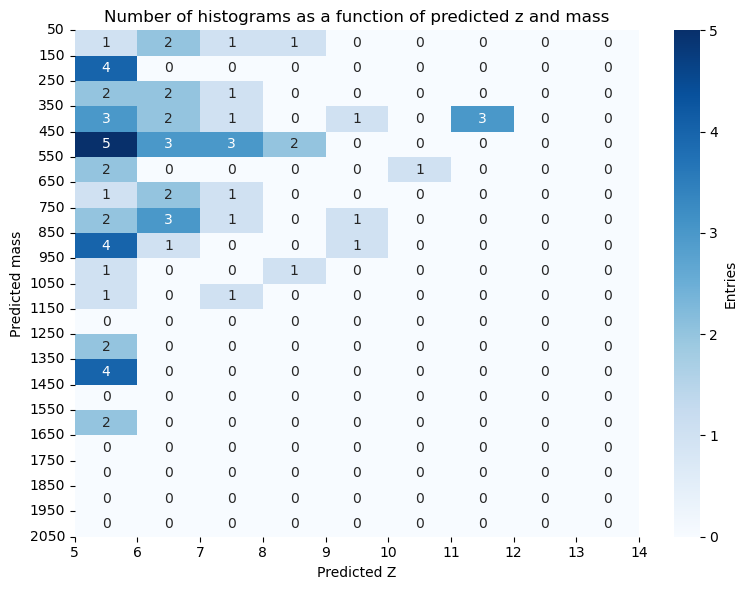

Saving analysis_plots/histograms_per_mass_per_z_model_1_threshold_5_all.png...
Ploting model 2_width_sig...
Total: 154
Z 5.049618 27.916521
M 227.0 2719.0


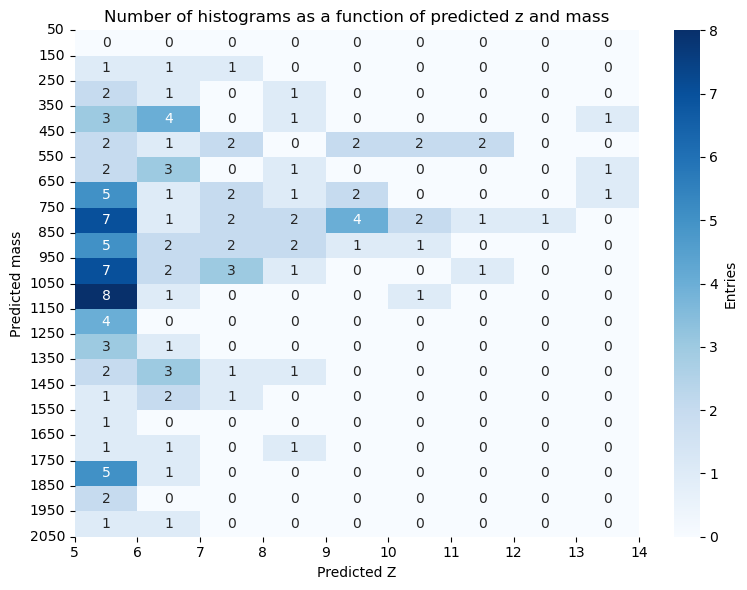

Saving analysis_plots/histograms_per_mass_per_z_model_2_threshold_5_all.png...
Ploting model 3_width_sig...
Total: 305
Z 5.002436 25.749483
M 233.0 3333.0


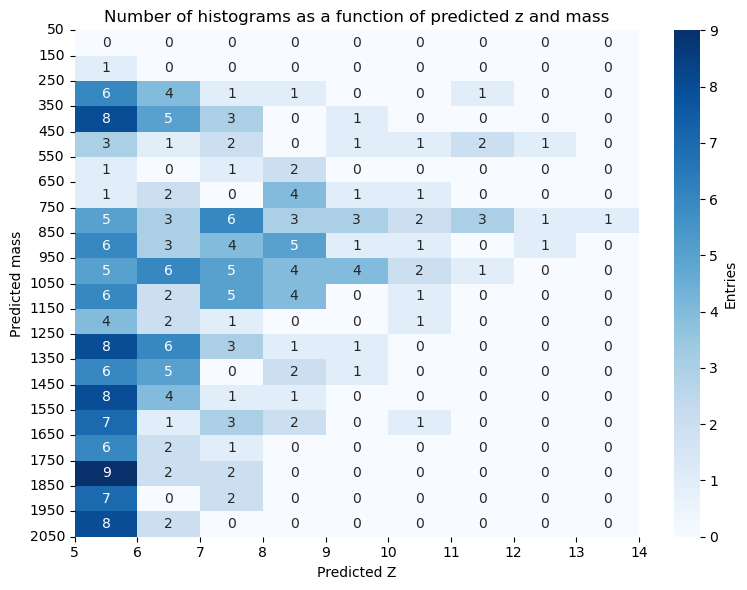

Saving analysis_plots/histograms_per_mass_per_z_model_3_threshold_5_all.png...
Ploting model 4_width_sig...
Total: 712
Z 5.001076 33.74177
M 211.0 4958.0


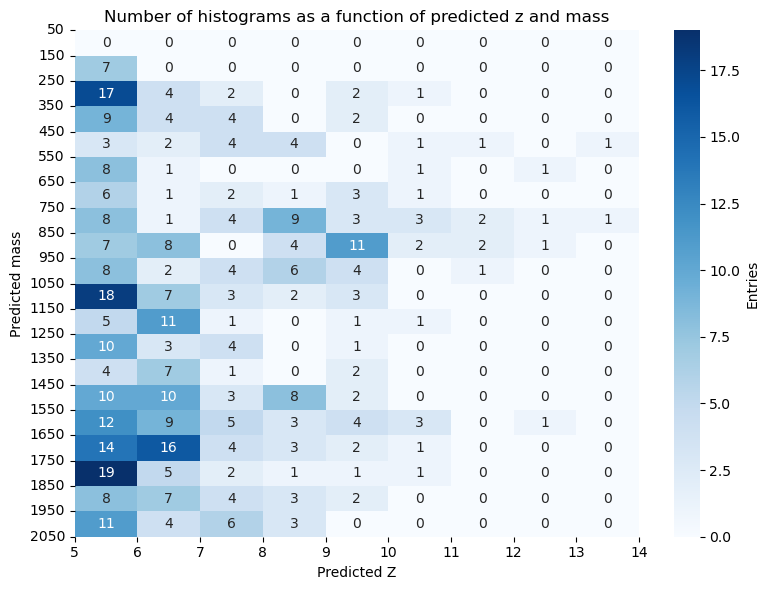

Saving analysis_plots/histograms_per_mass_per_z_model_4_threshold_5_all.png...


In [22]:
# Plot heatmaps
for tag, thr in product([1,2,3,4], [5]):
    print(f'Ploting model {tag}_width_sig...')
    
    df = dfs[tag]
    xdata = df[(df['zmax'] >= thr)]['zmax'].to_numpy()
    ydata = df[(df['zmax'] >= thr)]['mass'].to_numpy()
    
    print('Total:', xdata.shape[0])
    print('Z', np.min(xdata), np.max(xdata))
    print('M', np.min(ydata), np.max(ydata))
    
    x_binning = np.arange(thr, thr+10, 1)
    # x_binning = np.arange(5, 21, 15)
    y_binning = np.arange(50, 2150, 100)
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100, layout='tight')
    heatmap_data, x_binning, y_binning = np.histogram2d(xdata, ydata, bins=[x_binning, y_binning])
    ax = heatmap(heatmap_data.T, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': 'Entries'})
    ax.set_title('Number of histograms as a function of predicted z and mass')
    ax.set_xlabel('Predicted Z')
    ax.set_ylabel('Predicted mass')
    plt.xticks(np.arange(len(x_binning)), ['{}'.format(i) for i in x_binning], rotation='horizontal')
    plt.yticks(np.arange(len(y_binning)), ['{}'.format(i) for i in y_binning], rotation='horizontal')
    plt.show()
    
    # Save the plot
    subdir = 'analysis_plots'
    Path(f'{subdir}').mkdir(parents=True, exist_ok=True)
    output = f'{subdir}/histograms_per_mass_per_z_model_{tag}_threshold_{thr}_all.png'
    print(f'Saving {output}...')
    fig.savefig(output, dpi=300)
    plt.close(fig)

## Plot false positives

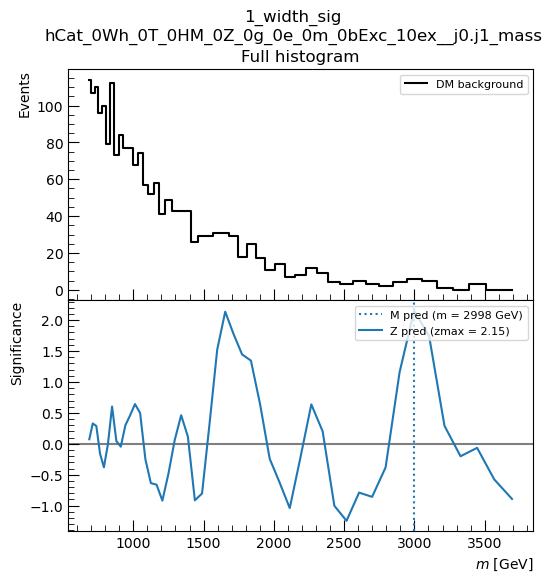

13133 11


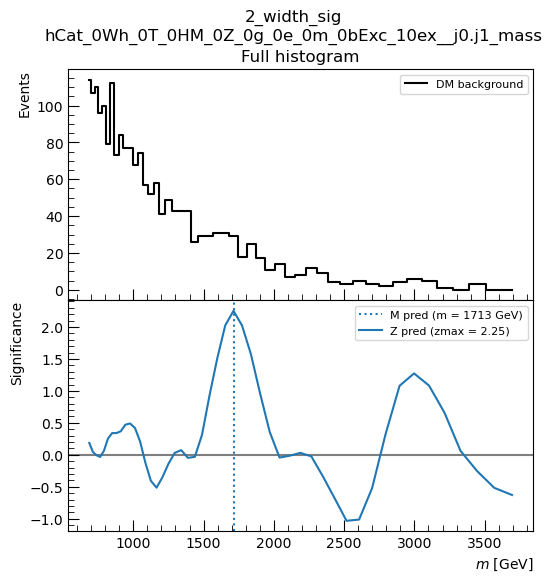

13133 11


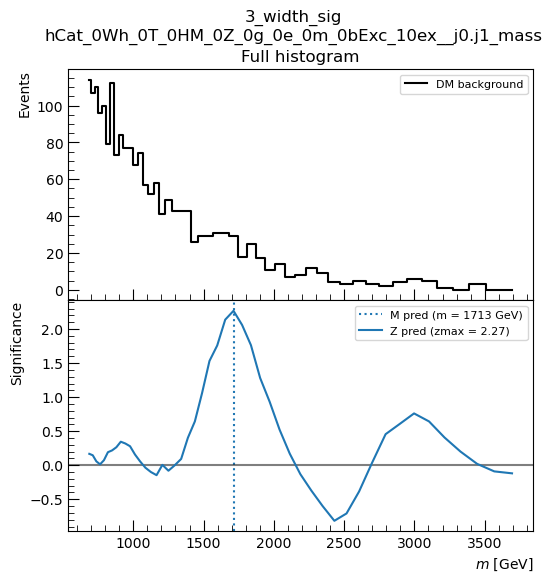

13133 11


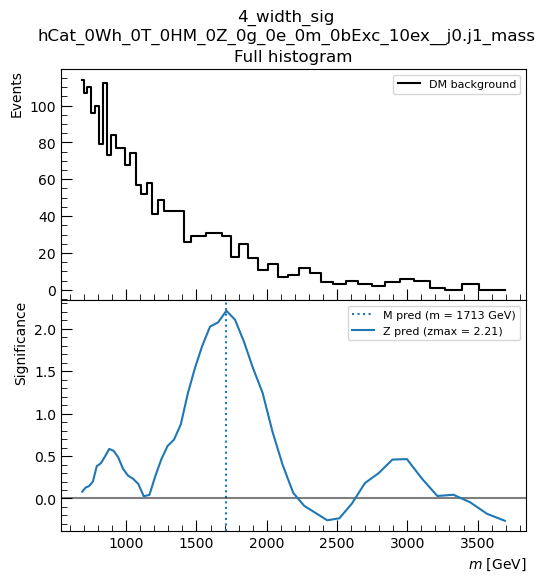

13133 11


In [23]:
# Plot false positives
for tag in [1,2,3,4]:

    plotted = []
    for i, hist_name in enumerate(data[tag]['C']):
    
        bin_edges = data[tag]['M'][i]
        bin_widths = np.array([bin_edges[i+1]-bin_edges[i] for i in range(0, len(bin_edges)-1)])
        x = bin_edges[:-1] + bin_widths/2
    
        obs = data[tag]['X'][i]
        # bkg = data[tag]['B'][i]
        zpred = data[tag]['zpred'][i]
        bpred = data[tag]['bpred'][i]
        zmax = np.nanmax(zpred)
        zmax_bin = np.argmax(zpred)
        mass = x[np.argmax(zpred)]
        
        # condition = hist_name in set(false_positives[1]) and hist_name in set(false_positives[2]) and hist_name in set(false_positives[3]) and hist_name in set(false_positives[4]) 
        condition = 'massT' not in hist_name and 'massMET' not in hist_name
        # condition = condition and zmax_bin > 10 and zmax_bin <= 15 and len(obs) <= 40
        if not condition: continue
        if len(plotted) > 10: continue
        plotted += [hist_name]
        
        # Plot
        gridspec_kw = {'height_ratios': [1,1], 'hspace': 0.0}
        fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6,6), sharex=True, 
                               gridspec_kw=gridspec_kw)

        ax[0].errorbar(x, obs, label=f'DM background', 
                       # marker='.', linestyle='', color='black')    
                       drawstyle='steps-mid', color='black')  
        ax[1].errorbar(x, zpred, label=f'Z pred (zmax = {zmax:.2f})', linestyle='-', color='tab:blue')
        ax[1].axvline(x[zmax_bin], label=f'M pred (m = {mass:.0f} GeV)', 
                      linestyle=':', color='tab:blue')
       
        for k in [0,1]:

            if k==0: ax[k].set_title(f'Full histogram')
            if k==0: ax[k].set_ylabel('Events', loc='top')
            if k==1: ax[k].set_ylabel('Significance', loc='top')
            if k==1: ax[k].set_xlabel('$m$ [GeV]', loc='right')
            if k in [1]: ax[k].axhline(0, color='black', alpha=0.5)
                
            ax[k].legend(loc='upper right', fontsize=8)
            ax[k].xaxis.set_minor_locator(AutoMinorLocator())
            ax[k].yaxis.set_minor_locator(AutoMinorLocator())
            ax[k].tick_params(which='both', axis='both', direction='in', top=False, right=False)
            ax[k].tick_params(which='major', axis='both', length=8)
            ax[k].tick_params(which='minor', axis='both', length=4)
        
        fig.suptitle(f'{tag}_width_sig\n{hist_name}')
    
        if len(plotted) < 2:
            plt.show()
        subdir = f'analysis_plots/false_positives/mass_zmax_leq_3/{tag}_sig/'
        Path(f'{subdir}').mkdir(parents=True, exist_ok=True)
        fig.savefig(f'{subdir}/{hist_name}.png', dpi=300)
        # fig.savefig(f'{subdir}/{hist_name}.png', dpi=300)
        plt.close(fig)
    print(i+1, len(plotted))  


## Distributions for different parameters

In [24]:
# False positives rate as a function of variables
for cut, condition in {
    'all' : lambda x : True,
    'massT' : lambda x : get_obs(x) == 'massT',
    'massMET' : lambda x : get_obs(x) == 'massMET',
    'mass' : lambda x : get_obs(x) == 'mass',
}.items():
    for thr in [3, 5, 7]:
        for var, (var_name, binning) in {
            'nbins' : ('Number of bins', np.arange(30, 150, 10)),
            'zmax_bin' : ('Bin position of prediction', np.arange(0, 150, 10)),
            'zmax' : ('Predicted Z', np.arange(thr, 15, 1)),
            'mass' : ('Predicted mass', np.arange(50, 2050, 100)),
            'obs' : ('Observables', ['mass', 'massT', 'massMET'])
        }.items():
            if var == 'obs' and cut != 'all': continue
            gridspec_kw = {'height_ratios': [1], 'hspace': 0.0}
            fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4), sharex=True, 
                                   gridspec_kw=gridspec_kw)
            
            for tag in [1,2,3,4]:
                df = dfs[tag][dfs[tag]['zmax'] >= thr]
                df = df[df['name'].apply(condition) == True]
    
                if var == 'obs':
                    obs_var = df['obs'].apply(get_obs)
                    obs_var_tot = dfs[tag]['obs'].apply(get_obs)
                    x = obs_var.value_counts().sort_index().index
                    y = obs_var.value_counts().sort_index().values
                    ytot = obs_var_tot.value_counts().sort_index().values
                    ax.errorbar(x, y/ytot, label=f'Model {tag}', drawstyle='steps-mid', marker='o')
                    
                else:
                    y, xbinning = np.histogram(df[var].to_numpy(), bins=binning)
                    x = xbinning[:-1]+np.diff(xbinning)/2
                    ax.errorbar(x, y, label=f'Model {tag}', drawstyle='steps-mid', marker='o')
    
                ax.set_title(f'Histograms with zmax ≥ {thr}')
                ax.set_ylabel('Entries', loc='top')
                ax.set_xlabel(var_name, loc='right')
                ax.legend(loc='upper right', fontsize=8)
                ax.xaxis.set_minor_locator(AutoMinorLocator())
                ax.yaxis.set_minor_locator(AutoMinorLocator())
                ax.tick_params(which='both', axis='both', direction='in', top=False, right=False)
                ax.tick_params(which='major', axis='both', length=8)
                ax.tick_params(which='minor', axis='both', length=4)
            
            # plt.show()
            subdir = f'analysis_plots'
            Path(f'{subdir}').mkdir(parents=True, exist_ok=True)
            file_name = f'{subdir}/false_positives_{cut}_zmax_{thr}_vs_{var}.png'
            print(file_name)
            fig.savefig(file_name, dpi=300)
            plt.close(fig)

analysis_plots/false_positives_all_zmax_3_vs_nbins.png
analysis_plots/false_positives_all_zmax_3_vs_zmax_bin.png
analysis_plots/false_positives_all_zmax_3_vs_zmax.png
analysis_plots/false_positives_all_zmax_3_vs_mass.png
analysis_plots/false_positives_all_zmax_3_vs_obs.png
analysis_plots/false_positives_all_zmax_5_vs_nbins.png
analysis_plots/false_positives_all_zmax_5_vs_zmax_bin.png
analysis_plots/false_positives_all_zmax_5_vs_zmax.png
analysis_plots/false_positives_all_zmax_5_vs_mass.png
analysis_plots/false_positives_all_zmax_5_vs_obs.png
analysis_plots/false_positives_all_zmax_7_vs_nbins.png
analysis_plots/false_positives_all_zmax_7_vs_zmax_bin.png
analysis_plots/false_positives_all_zmax_7_vs_zmax.png
analysis_plots/false_positives_all_zmax_7_vs_mass.png
analysis_plots/false_positives_all_zmax_7_vs_obs.png
analysis_plots/false_positives_massT_zmax_3_vs_nbins.png
analysis_plots/false_positives_massT_zmax_3_vs_zmax_bin.png
analysis_plots/false_positives_massT_zmax_3_vs_zmax.png
analy

In [34]:
# Heatmap of two observables
# Plot heatmaps
for cut, condition in {
    'all' : lambda x : True,
    'massT' : lambda x : get_obs(x) == 'massT',
    'massMET' : lambda x : get_obs(x) == 'massMET',
    'mass' : lambda x : get_obs(x) == 'mass',
}.items():
    for tag, thr in product([1,2,3,4], [5]):
        print(f'Ploting model {tag}_width_sig, thr {thr}, cut {cut}...')
        
        df = dfs[tag]
        df = df[df['name'].apply(condition) == True]
        xdata = df[(df['zmax'] >= thr)]['zmax_bin'].to_numpy()
        ydata = df[(df['zmax'] >= thr)]['nbins'].to_numpy()
        
        print('Total:', xdata.shape[0], ydata.shape[0])
        print('X', np.min(xdata), np.max(xdata))
        print('Y', np.min(ydata), np.max(ydata))
        # continue
    
        # x_binning = np.arange(30, 150, 10)
        # y_binning = np.arange(0, 150, 10)
    
        x_binning = np.arange(0, 55, 5)
        y_binning = np.arange(30, 200, 10)
        
        fig, ax = plt.subplots(figsize=(8, 6), dpi=100, layout='tight')
        heatmap_data, x_binning, y_binning = np.histogram2d(xdata, ydata, bins=[x_binning, y_binning])
        if xdata.shape[0] != np.sum(heatmap_data):
            print('Heatmap not showing all predictions!')
        ax = heatmap(heatmap_data.T, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label': 'Entries'})
        ax.set_title('Number of histograms as a function of bin position and number of bins')
        ax.set_xlabel('Bin position')
        ax.set_ylabel('Number of bins')
        plt.xticks(np.arange(len(x_binning)), ['{}'.format(i) for i in x_binning], rotation='horizontal')
        plt.yticks(np.arange(len(y_binning)), ['{}'.format(i) for i in y_binning], rotation='horizontal')
        # plt.show()
        
        # Save the plot
        subdir = 'analysis_plots/'
        Path(f'{subdir}').mkdir(parents=True, exist_ok=True)
        output = f'{subdir}/histograms_per_zmaxbin_per_nbins_model_{tag}_threshold_{thr}_{cut}.png'
        print(f'Saving {output}...')
        fig.savefig(output, dpi=300)
        plt.close(fig)


Ploting model 1_width_sig, thr 5, cut all...
Total: 75 75
X 1 32
Y 31 184
Saving analysis_plots//histograms_per_zmaxbin_per_nbins_model_1_threshold_5_all.png...
Ploting model 2_width_sig, thr 5, cut all...
Total: 154 154
X 4 40
Y 31 184
Saving analysis_plots//histograms_per_zmaxbin_per_nbins_model_2_threshold_5_all.png...
Ploting model 3_width_sig, thr 5, cut all...
Total: 305 305
X 2 50
Y 31 184
Saving analysis_plots//histograms_per_zmaxbin_per_nbins_model_3_threshold_5_all.png...
Ploting model 4_width_sig, thr 5, cut all...
Total: 712 712
X 7 52
Y 31 184
Heatmap not showing all predictions!
Saving analysis_plots//histograms_per_zmaxbin_per_nbins_model_4_threshold_5_all.png...
Ploting model 1_width_sig, thr 5, cut massT...
Total: 23 23
X 1 26
Y 31 94
Saving analysis_plots//histograms_per_zmaxbin_per_nbins_model_1_threshold_5_massT.png...
Ploting model 2_width_sig, thr 5, cut massT...
Total: 51 51
X 5 26
Y 31 94
Saving analysis_plots//histograms_per_zmaxbin_per_nbins_model_2_threshold_

## Apply cuts

In [10]:
low_mass_bumps = [
    # Model 1
    'hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_3ex__j1.j2_mass',
    'hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_4ex__j1.j3_mass',
    'hCat_0Wh_0T_0HM_0Z_0g_0e_0m_0bExc_5ex__j2.j3_mass',
    'hCat_0Wh_0T_0HM_0Z_0g_0e_0m_incl_4ex__j0.j3_mass',
    'hCat_0Wh_0T_0HM_0Z_0g_0e_0m_incl_4ex__j1.j3_mass',
    'hCat_0Wh_0T_0HM_0Z_0g_0e_0m_incl_5ex__j2.j3_mass',
    'hCat_0Wh_0T_0HM_0Z_0g_0e_0m_incl_8ex__j2.j3_mass',
    'hCat_1Wh_0T_0HM_0Z_0g_0e_0m_0bExc_4ex__j2.j3_mass'
]

In [13]:
# Define cuts to apply
def cuts(row):
    if row['zmax_bin'] <= 10: return False
    if row['zmax_bin'] > 15: return False
    # if row['nbins'] < 30 or row['nbins'] > 35: return False
    # if not 'massT' in row['name']: return False
    # if not 'massMET' in row['name']: return False
    # if 'massT' in row['name']: return False
    # if 'massMET' in row['name']: return True
    # else: return False
    # if row['name'] in set(low_mass_bumps): return False
    return True

# Apply cuts
dfs_cuts = {}
for tag in [1,2,3,4]:
    
    df = dfs[tag]
    print(f'Model {tag}')
    print(f'- {df[(df["zmax"] >= 5) & (df["zmax_bin"] <= 10)].shape[0]} histograms with zmax_bin <= 10')
    print(f'- {df[(df["zmax"] >= 5) & (df["zmax_bin"] > 10) & (df["zmax_bin"] <= 20)].shape[0]} histograms with 10 < zmax_bin <= 20')
    massT = [o for o in df[(df["zmax"] >= 5)]['obs'].to_numpy() if 'massT' in o]
    print(f'- {len(massT)} massT histograms out of {df[(df["zmax"] >= 5)].shape[0]}')
    massMET = [o for o in df[(df["zmax"] >= 5)]['obs'].to_numpy() if 'massMET' in o]
    print(f'- {len(massMET)} massMET histograms out of {df[(df["zmax"] >= 5)].shape[0]}')
    df['cuts'] = df.apply(cuts, axis=1)
    dfs_cuts[tag] = df[(df['cuts'] == True)]

# Print statistics after cuts
final_states = np.unique([h.split('__') for h in dfs_cuts[1]["name"]])
print(f'{dfs_cuts[1]["name"].shape[0]} histograms ({dfs_cuts[1]["name"].unique().shape[0]} unique ones)\n'
      f'  {final_states.shape[0]} final states\n'
      f'  {dfs_cuts[1]["nbins"].min()} <= Nbins <= {dfs_cuts[1]["nbins"].max()}\n'
      f'  {dfs_cuts[1]["ymin"].min()} <= entries per bin <= {dfs_cuts[1]["ymax"].max()}\n'
      f'  {dfs_cuts[1]["xmin"].min()} <= mass <= {dfs_cuts[1]["xmax"].max()}'
      )

Model 1
- 32 histograms with zmax_bin <= 10
- 34 histograms with 10 < zmax_bin <= 20
- 23 massT histograms out of 75
- 18 massMET histograms out of 75
Model 2
- 31 histograms with zmax_bin <= 10
- 92 histograms with 10 < zmax_bin <= 20
- 51 massT histograms out of 154
- 58 massMET histograms out of 154
Model 3
- 38 histograms with zmax_bin <= 10
- 174 histograms with 10 < zmax_bin <= 20
- 92 massT histograms out of 305
- 108 massMET histograms out of 305
Model 4
- 70 histograms with zmax_bin <= 10
- 313 histograms with 10 < zmax_bin <= 20
- 197 massT histograms out of 712
- 220 massMET histograms out of 712
7201 histograms (7184 unique ones)
  1754 final states
  31 <= Nbins <= 158
  0.0 <= entries per bin <= 94770.0
  51.0 <= mass <= 9086.0


In [14]:
# Get false positives
table_data = [['', 'zmax ≥ 3', 'zmax ≥ 4', 'zmax ≥ 5', 'zmax ≥ 6', 'zmax ≥ 7']]

false_positives = {}
for tag in [1,2,3,4]:
    
    df = dfs_cuts[tag]
    tot = df['name'].shape[0]
    zmax3 = df[df['zmax'] >= 3]['name'].shape[0]
    zmax4 = df[df['zmax'] >= 4]['name'].shape[0]
    zmax5 = df[df['zmax'] >= 5]['name'].shape[0]
    zmax6 = df[df['zmax'] >= 6]['name'].shape[0]
    zmax7 = df[df['zmax'] >= 7]['name'].shape[0]
    s = lambda x : f'{(x/tot)*100:.1f}% ({x}/{tot}) '

    table_data += [[f'Model {tag}', s(zmax3), s(zmax4), s(zmax5), s(zmax6), s(zmax7)]]
    
    df_out = df[df['zmax'] >= 5]['name']
    false_positives[tag] = df_out.to_numpy()
    # out_file = f'bkg_only_false_positives_{tag}.csv'
    # df_out.to_csv(out_file, index=False, header=False)


print(tabulate(table_data, headers='firstrow',
               tablefmt='rounded_outline', floatfmt=".4g"))
    

╭─────────┬───────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────────╮
│         │ zmax ≥ 3          │ zmax ≥ 4        │ zmax ≥ 5        │ zmax ≥ 6        │ zmax ≥ 7       │
├─────────┼───────────────────┼─────────────────┼─────────────────┼─────────────────┼────────────────┤
│ Model 1 │ 6.4% (464/7201)   │ 1.1% (82/7201)  │ 0.4% (32/7201)  │ 0.3% (19/7201)  │ 0.2% (13/7201) │
│ Model 2 │ 6.7% (486/7255)   │ 1.8% (131/7255) │ 1.0% (74/7255)  │ 0.7% (50/7255)  │ 0.5% (37/7255) │
│ Model 3 │ 10.5% (769/7302)  │ 4.3% (316/7302) │ 1.7% (123/7302) │ 1.0% (75/7302)  │ 0.8% (59/7302) │
│ Model 4 │ 20.0% (1214/6060) │ 8.8% (534/6060) │ 4.2% (252/6060) │ 1.8% (110/6060) │ 1.1% (65/6060) │
╰─────────┴───────────────────┴─────────────────┴─────────────────┴─────────────────┴────────────────╯


In [19]:
# Get false positives with condition
for cut, condition in {
    'massT' : lambda x : get_obs(x) == 'massT',
    'massMET' : lambda x : get_obs(x) == 'massMET',
    'mass' : lambda x : get_obs(x) == 'mass',
}.items():
    print(f'Cut: {cut}')
    table_data = [['', 'zmax ≥ 3', 'zmax ≥ 4', 'zmax ≥ 5', 'zmax ≥ 6', 'zmax ≥ 7']]
    
    false_positives[cut] = {}
    for tag in [1,2,3,4]:

        df = dfs_cuts[tag]
        df = df[df['name'].apply(condition) == True]
        tot = df['name'].shape[0]
        zmax3 = df[df['zmax'] >= 3]['name'].shape[0]
        zmax4 = df[df['zmax'] >= 4]['name'].shape[0]
        zmax5 = df[df['zmax'] >= 5]['name'].shape[0]
        zmax6 = df[df['zmax'] >= 6]['name'].shape[0]
        zmax7 = df[df['zmax'] >= 7]['name'].shape[0]
        s = lambda x : f'{(x/tot)*100:.1f}% ({x}/{tot}) '
    
        table_data += [[f'Model {tag}', s(zmax3), s(zmax4), s(zmax5), s(zmax6), s(zmax7)]]
        
        df_out = df[df['zmax'] >= 5]['name']
        false_positives[cut][tag] = df_out.to_numpy()
        # out_file = f'bkg_only_false_positives_{tag}.csv'
        # df_out.to_csv(out_file, index=False, header=False)
    
    
    print(tabulate(table_data, headers='firstrow',
                   tablefmt='rounded_outline', floatfmt=".4g"))
    

Cut: massT
╭─────────┬─────────────────┬────────────────┬───────────────┬───────────────┬───────────────╮
│         │ zmax ≥ 3        │ zmax ≥ 4       │ zmax ≥ 5      │ zmax ≥ 6      │ zmax ≥ 7      │
├─────────┼─────────────────┼────────────────┼───────────────┼───────────────┼───────────────┤
│ Model 1 │ 9.5% (103/1085) │ 2.0% (22/1085) │ 0.8% (9/1085) │ 0.6% (6/1085) │ 0.4% (4/1085) │
│ Model 2 │ 11.2% (101/898) │ 4.2% (38/898)  │ 2.9% (26/898) │ 2.1% (19/898) │ 1.7% (15/898) │
│ Model 3 │ 12.9% (110/854) │ 7.0% (60/854)  │ 3.3% (28/854) │ 2.6% (22/854) │ 2.2% (19/854) │
│ Model 4 │ 24.9% (146/586) │ 14.5% (85/586) │ 9.4% (55/586) │ 4.8% (28/586) │ 3.4% (20/586) │
╰─────────┴─────────────────┴────────────────┴───────────────┴───────────────┴───────────────╯
Cut: massMET
╭─────────┬──────────────────┬────────────────┬───────────────┬───────────────┬───────────────╮
│         │ zmax ≥ 3         │ zmax ≥ 4       │ zmax ≥ 5      │ zmax ≥ 6      │ zmax ≥ 7      │
├─────────┼─────────────

## Plot heatmaps 

Ploting model 1_width_sig...
Total: 8
Z 5.7838917 6.797703
M 645.0 1527.0


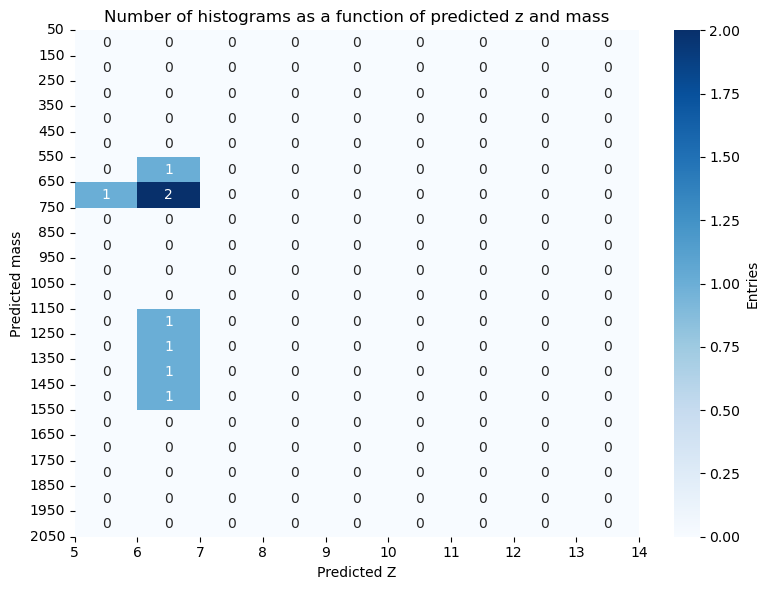

Saving analysis_plots/false_positives/histograms_per_mass_per_z_model_1_threshold_5.png...
Ploting model 2_width_sig...
Total: 43
Z 5.107419 12.206005
M 546.0 4481.0


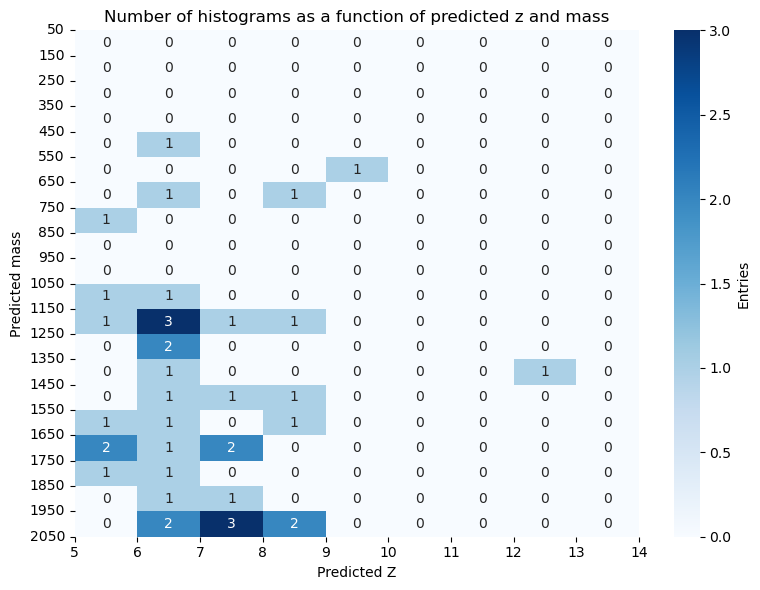

Saving analysis_plots/false_positives/histograms_per_mass_per_z_model_2_threshold_5.png...
Ploting model 3_width_sig...
Total: 55
Z 5.0073295 13.920891
M 681.0 2603.0


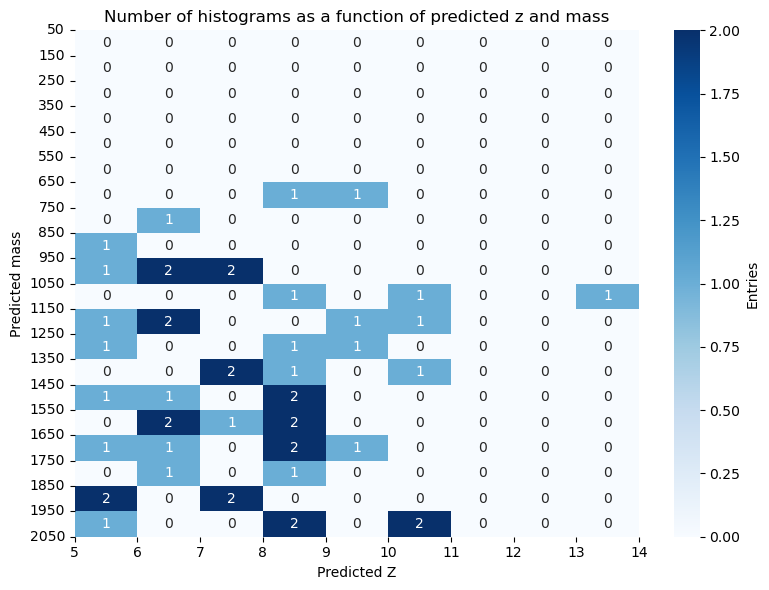

Saving analysis_plots/false_positives/histograms_per_mass_per_z_model_3_threshold_5.png...
Ploting model 4_width_sig...
Total: 71
Z 5.06578 10.295942
M 371.0 4481.0


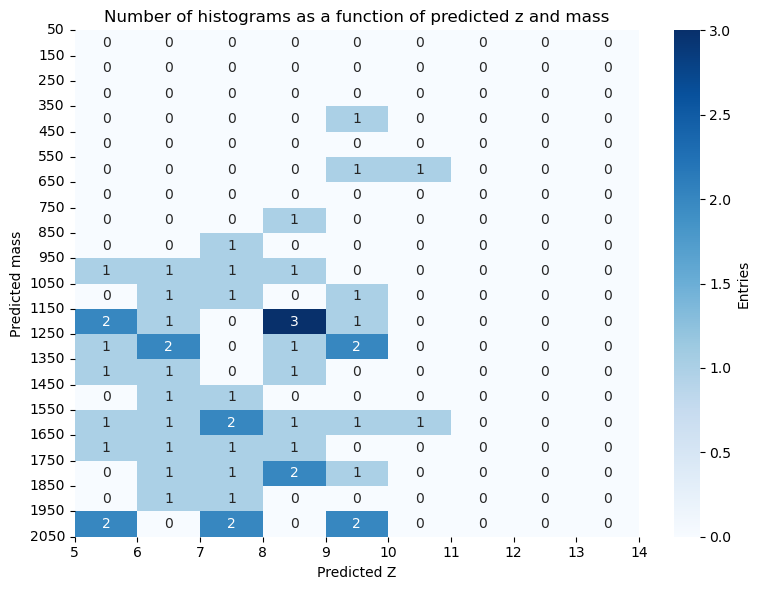

Saving analysis_plots/false_positives/histograms_per_mass_per_z_model_4_threshold_5.png...


In [15]:
# Plot heatmaps
for tag, thr in product([1,2,3,4], [5]):
    print(f'Ploting model {tag}_width_sig...')
    
    df = dfs_cuts[tag]
    xdata = df[(df['zmax'] >= thr)]['zmax'].to_numpy()
    ydata = df[(df['zmax'] >= thr)]['mass'].to_numpy()
    
    print('Total:', xdata.shape[0])
    print('Z', np.min(xdata), np.max(xdata))
    print('M', np.min(ydata), np.max(ydata))
    
    x_binning = np.arange(thr, thr+10, 1)
    # x_binning = np.arange(5, 21, 15)
    y_binning = np.arange(50, 2150, 100)
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100, layout='tight')
    heatmap_data, x_binning, y_binning = np.histogram2d(xdata, ydata, bins=[x_binning, y_binning])
    ax = heatmap(heatmap_data.T, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': 'Entries'})
    ax.set_title('Number of histograms as a function of predicted z and mass')
    ax.set_xlabel('Predicted Z')
    ax.set_ylabel('Predicted mass')
    plt.xticks(np.arange(len(x_binning)), ['{}'.format(i) for i in x_binning], rotation='horizontal')
    plt.yticks(np.arange(len(y_binning)), ['{}'.format(i) for i in y_binning], rotation='horizontal')
    plt.show()
    
    # Save the plot
    subdir = 'analysis_plots/false_positives'
    Path(f'{subdir}').mkdir(parents=True, exist_ok=True)
    output = f'{subdir}/histograms_per_mass_per_z_model_{tag}_threshold_{thr}.png'
    print(f'Saving {output}...')
    fig.savefig(output, dpi=300)
    plt.close(fig)

## Plot selected histograms

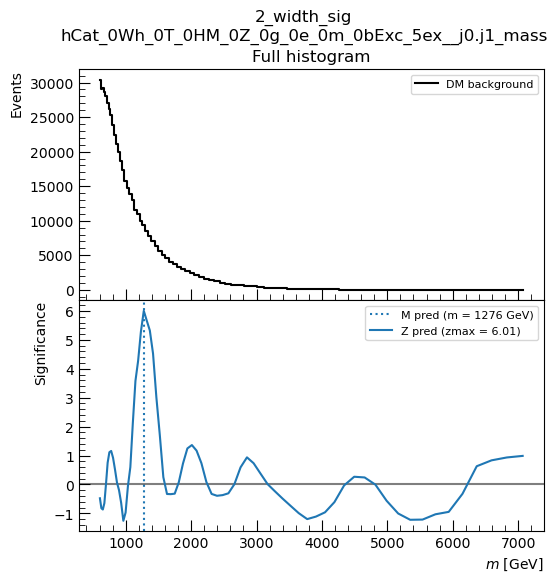

13133 5


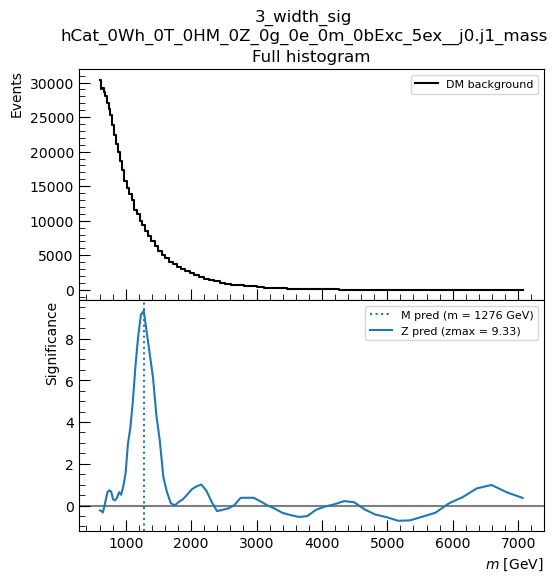

13133 7


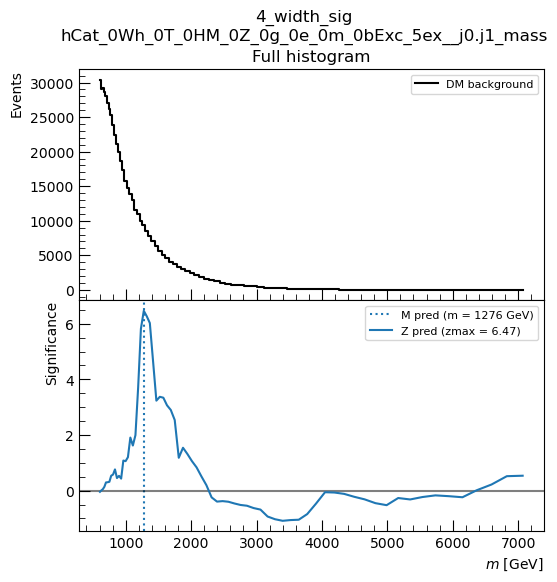

13133 8


In [29]:
# Plot false positives for all models for given condition
for tag in [2,3,4]:

    plotted = []
    for i, hist_name in enumerate(data[tag]['C']):
    
        bin_edges = data[tag]['M'][i]
        bin_widths = np.array([bin_edges[i+1]-bin_edges[i] for i in range(0, len(bin_edges)-1)])
        x = bin_edges[:-1] + bin_widths/2
    
        obs = data[tag]['X'][i]
        # bkg = data[tag]['B'][i]
        zpred = data[tag]['zpred'][i]
        bpred = data[tag]['bpred'][i]
        zmax = np.nanmax(zpred)
        zmax_bin = np.argmax(zpred)
        mass = x[np.argmax(zpred)]
        
        condition = hist_name in set(false_positives[2]) and hist_name in set(false_positives[3]) and hist_name in set(false_positives[4]) 
        condition = condition and mass >= 1250 and mass <= 2050
        if not condition: continue
        # if len(plotted) > 10: continue
        plotted += [hist_name]
        
        # Plot
        gridspec_kw = {'height_ratios': [1,1], 'hspace': 0.0}
        fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6,6), sharex=True, 
                               gridspec_kw=gridspec_kw)

        ax[0].errorbar(x, obs, label=f'DM background', 
                       # marker='.', linestyle='', color='black')    
                       drawstyle='steps-mid', color='black')  
        ax[1].errorbar(x, zpred, label=f'Z pred (zmax = {zmax:.2f})', linestyle='-', color='tab:blue')
        ax[1].axvline(x[zmax_bin], label=f'M pred (m = {mass:.0f} GeV)', 
                      linestyle=':', color='tab:blue')
       
        for k in [0,1]:

            if k==0: ax[k].set_title(f'Full histogram')
            if k==0: ax[k].set_ylabel('Events', loc='top')
            if k==1: ax[k].set_ylabel('Significance', loc='top')
            if k==1: ax[k].set_xlabel('$m$ [GeV]', loc='right')
            if k in [1]: ax[k].axhline(0, color='black', alpha=0.5)
                
            ax[k].legend(loc='upper right', fontsize=8)
            ax[k].xaxis.set_minor_locator(AutoMinorLocator())
            ax[k].yaxis.set_minor_locator(AutoMinorLocator())
            ax[k].tick_params(which='both', axis='both', direction='in', top=False, right=False)
            ax[k].tick_params(which='major', axis='both', length=8)
            ax[k].tick_params(which='minor', axis='both', length=4)
        
        fig.suptitle(f'{tag}_width_sig\n{hist_name}')
    
        if len(plotted) < 2:
            plt.show()
        subdir = f'analysis_plots/false_positives/mass1800/{tag}_sig/'
        Path(f'{subdir}').mkdir(parents=True, exist_ok=True)
        fig.savefig(f'{subdir}/{hist_name}.png', dpi=300)
        # fig.savefig(f'{subdir}/{hist_name}.png', dpi=300)
        plt.close(fig)
    print(i+1, len(plotted))  

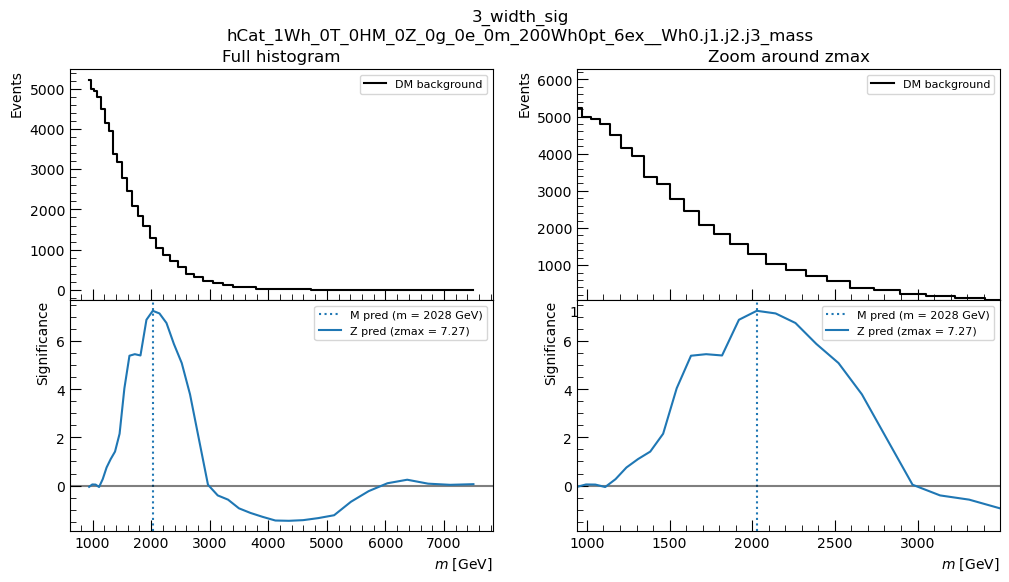

13133 2


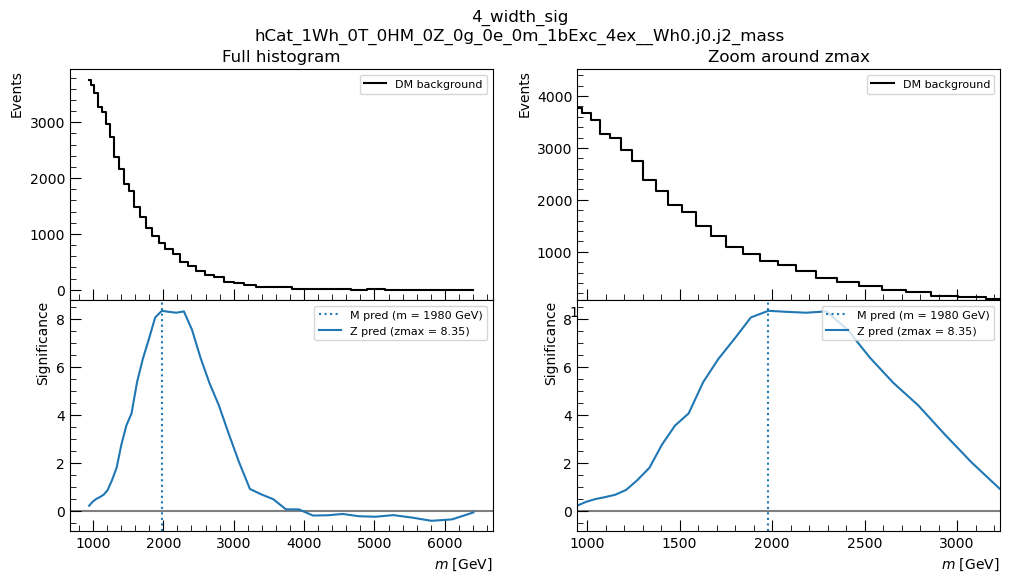

13133 3


In [34]:
# Plot false positives with zoom for all models for given condition
for tag in [1,2,3,4]:

    plotted = []
    for i, hist_name in enumerate(data[tag]['C']):
    
        bin_edges = data[tag]['M'][i]
        bin_widths = np.array([bin_edges[i+1]-bin_edges[i] for i in range(0, len(bin_edges)-1)])
        x = bin_edges[:-1] + bin_widths/2
    
        obs = data[tag]['X'][i]
        # bkg = data[tag]['B'][i]
        zpred = data[tag]['zpred'][i]
        bpred = data[tag]['bpred'][i]
        zmax = np.nanmax(zpred)
        zmax_bin = np.argmax(zpred)
        mass = x[np.argmax(zpred)]
        
        condition = hist_name in set(false_positives[2]) and hist_name in set(false_positives[3]) and hist_name in set(false_positives[4]) 
        condition = condition and mass >= 1450 and mass <= 2050
        if not condition: continue
        if len(plotted) > 10: continue
        plotted += [hist_name]
        
        # Plot
        gridspec_kw = {'height_ratios': [1,1], 'hspace': 0.0}
        fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(2*6,6), sharex=False, 
                               gridspec_kw=gridspec_kw)

        ax[0,0].errorbar(x, obs, label=f'DM background', 
                       # marker='.', linestyle='', color='black')    
                       drawstyle='steps-mid', color='black')  
        ax[1,0].errorbar(x, zpred, label=f'Z pred (zmax = {zmax:.2f})', linestyle='-', color='tab:blue')
        ax[1,0].axvline(x[zmax_bin], label=f'M pred (m = {mass:.0f} GeV)', 
                      linestyle=':', color='tab:blue')
        
        ax[0,1].errorbar(x, obs, label=f'DM background', 
                       # marker='.', linestyle='', color='black')    
                       drawstyle='steps-mid', color='black')  
        ax[1,1].errorbar(x, zpred, label=f'Z pred (zmax = {zmax:.2f})', linestyle='-', color='tab:blue')
        ax[1,1].axvline(x[zmax_bin], label=f'M pred (m = {mass:.0f} GeV)', 
                      linestyle=':', color='tab:blue')
       
        for k,j in product([0,1], [0,1]):
            # Zoom around prediction
            if j == 1:
                # imin = np.argmax(zpred)-10 if np.argmax(zpred)-10 > 0 else 0
                imin = 0
                imax = np.argmax(zpred)+10 if np.argmax(zpred)+10 < x.shape[0] else -1
                # for v,value in enumerate(bin_edges[:-1]):
                #     if v < imax: ax[0].text(bin_edges[v], 1.05*obs[v], f'{value:.0f}', fontsize=8)
                ax[k,j].set_xlim(x[imin], x[imax])
                if k==0: ax[0,j].set_ylim(bottom=0.8*obs[imax], top=1.2*obs[0])
            
            # if k in [0,1]: ax[k].set_ylabel('Events', loc='top')
            # if k in [1]: ax[k].set_ylim(bottom=0)
            # if k==2: ax[k].set_ylabel('Significance', loc='top')
            # ax[k].legend(loc='upper right', fontsize=8)
            # if k==2: ax[k].set_xlabel('$m$ [GeV]', loc='right')
            # if k==0: ax[k].set_title(f'{tag}_width_sig\n{hist_name}')
            # if k in [2]: ax[k].axhline(0, color='black', alpha=0.5)

            if k==0 and j==0: ax[k,j].set_title(f'Full histogram')
            if k==0 and j==1: ax[k,j].set_title(f'Zoom around zmax')
            if k==0: ax[k,j].set_ylabel('Events', loc='top')
            if k==1: ax[k,j].set_ylabel('Significance', loc='top')
            if k==1: ax[k,j].set_xlabel('$m$ [GeV]', loc='right')
            if k in [1]: ax[k,j].axhline(0, color='black', alpha=0.5)
                
            ax[k,j].legend(loc='upper right', fontsize=8)
            ax[k,j].xaxis.set_minor_locator(AutoMinorLocator())
            ax[k,j].yaxis.set_minor_locator(AutoMinorLocator())
            ax[k,j].tick_params(which='both', axis='both', direction='in', top=False, right=False)
            ax[k,j].tick_params(which='major', axis='both', length=8)
            ax[k,j].tick_params(which='minor', axis='both', length=4)
        fig.suptitle(f'{tag}_width_sig\n{hist_name}')
    
        if len(plotted) < 2:
            plt.show()
        subdir = f'analysis_plots/false_positives/mass1800/{tag}_sig/'
        Path(f'{subdir}').mkdir(parents=True, exist_ok=True)
        fig.savefig(f'{subdir}/{hist_name}.png', dpi=300)
        # fig.savefig(f'{subdir}/{hist_name}.png', dpi=300)
        plt.close(fig)
    print(i+1, len(plotted))  

## Dump all histograms into PDF

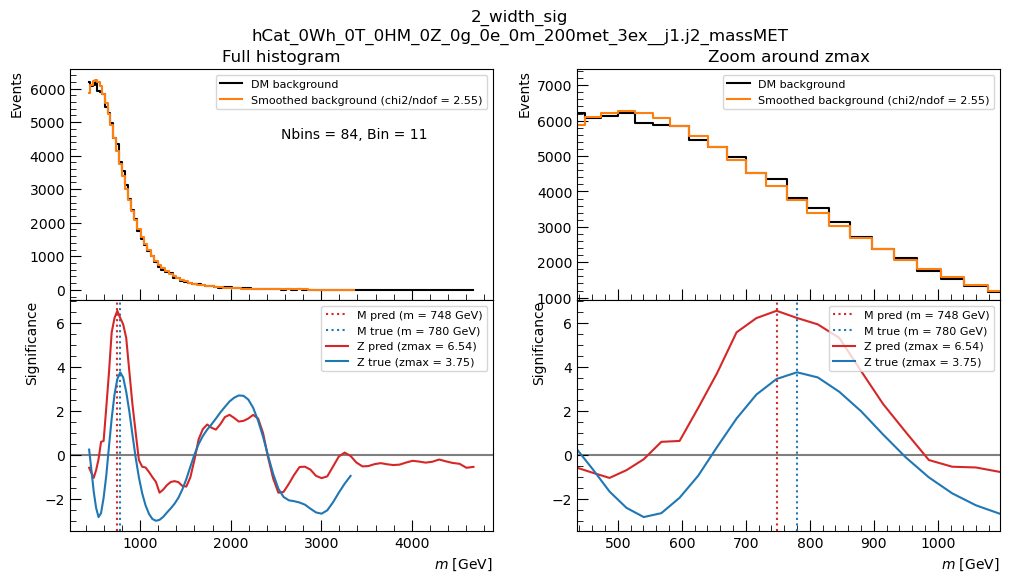

33120 28


Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an a

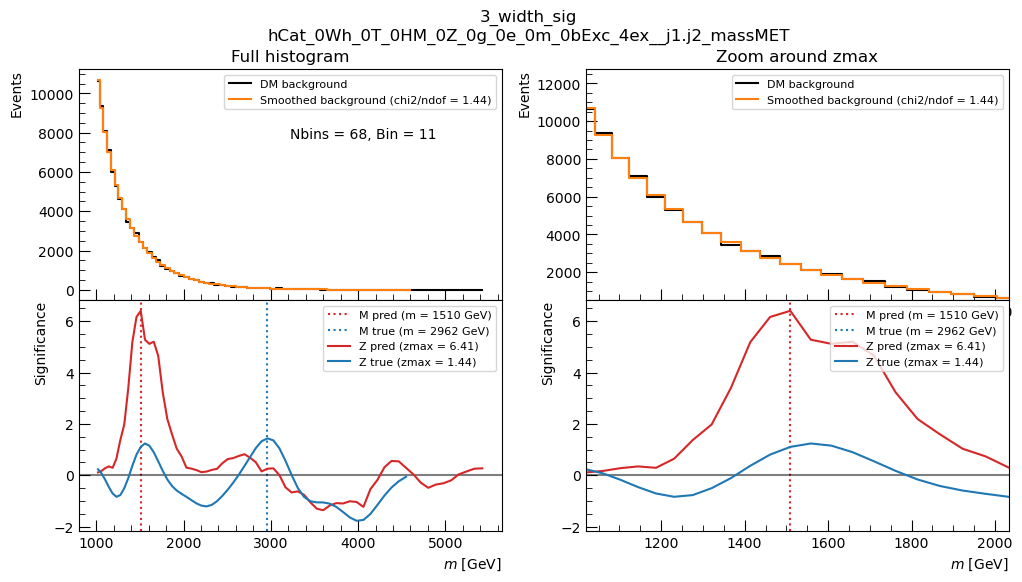

/home/bpascualdias/Physics/PhD/Research/DDP/2023-11_Amit_models_on_Eva_sample/workspace.py:85: RuntimeWarning: divide by zero encountered in divide
  hist = hist/np.sum(hist)
/home/bpascualdias/Physics/PhD/Research/DDP/2023-11_Amit_models_on_Eva_sample/workspace.py:85: RuntimeWarning: invalid value encountered in divide
  hist = hist/np.sum(hist)


33120 44


Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an a

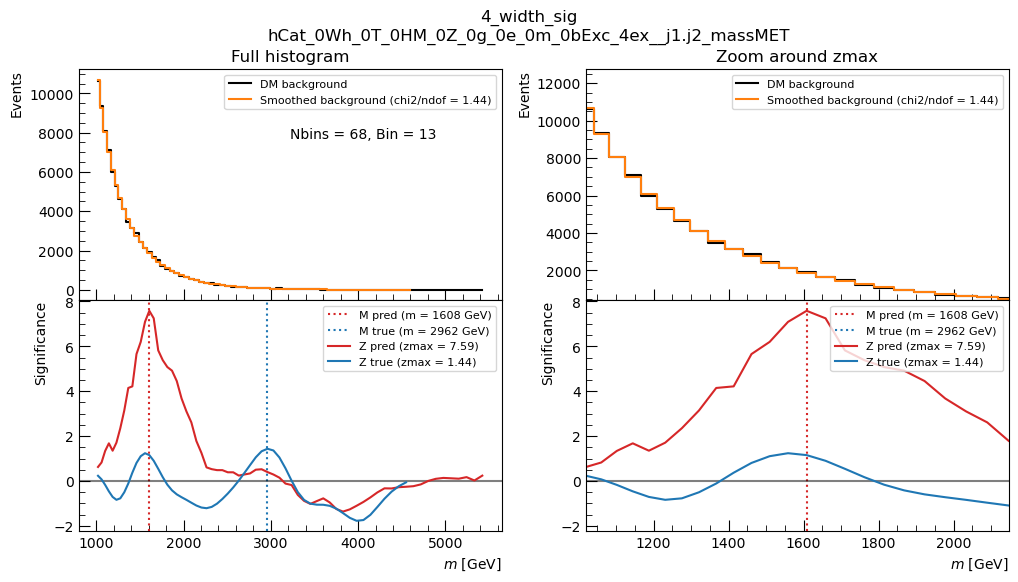

33120 42


Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an a

In [18]:
# Plot false positives with zoom for given tag
zoom = True
for tag in [2,3,4]:

    plotted = []
    for i, hist_name in enumerate(data[tag]['C']):

        condition = hist_name in set(false_positives[tag])
        # condition = np.all([hist_name in set(false_positives[m]) for m in [1,2,3,4]])
        condition = condition and 'massMET' in hist_name
        if not condition: continue
        # if len(plotted) > 10: continue
        plotted += [hist_name]
    
        bin_edges = data[tag]['M'][i]
        bin_widths = np.array([bin_edges[i+1]-bin_edges[i] for i in range(0, len(bin_edges)-1)])
        x = bin_edges[:-1] + bin_widths/2
    
        obs = data[tag]['X'][i]
        # bkg = data[tag]['B'][i]
        zpred = data[tag]['zpred'][i]
        bpred = data[tag]['bpred'][i]
        zmax = np.nanmax(zpred)
        zmax_bin = np.argmax(zpred)
        mass = x[np.argmax(zpred)]

        # Get smoothed background
        func, chi2 = smooth(obs)
        pad = len(obs) - len(func)
        bkg = np.array(list(func) + [None]*pad)

        # Get zPL
        w = Workspace()
        w.data = obs[:func.shape[0]]
        w.bkg_hist  = func
        w.bin_edges = bin_edges[:func.shape[0]+1]
        w.sig_func  = gaussian
        w.M  = 1000
        w.W = tag
        w.update()
        zt = w.z_scan()
        zt_max = np.nanmax(zt)
        zt_bin = np.argmax(zt)
        zt_mass = x[np.argmax(zt)]
        zt = np.array(list(zt) + [None]*pad)
 
        
        # Plot
        ncols = 2 if zoom else 1
        gridspec_kw = {'height_ratios': [1,1], 'hspace': 0.0}
        fig, ax = plt.subplots(nrows=2, ncols=ncols, figsize=(ncols*6,6), sharex=False, 
                               gridspec_kw=gridspec_kw)
        if not zoom: ax = ax[:,None]
        
        for j in range(ncols):
            ax[0,j].errorbar(x, obs, label=f'DM background', 
                           # marker='.', linestyle='', color='black')    
                           drawstyle='steps-mid', color='black')  
            ax[0,j].errorbar(x, bkg, label=f'Smoothed background (chi2/ndof = {chi2:.2f})', 
                           # marker='.', linestyle='', color='black')    
                           drawstyle='steps-mid', color='tab:orange')  
            # ax[0,j].errorbar(x, bpred, label=f'Predicted background', 
            #                # marker='.', linestyle='', color='black')    
            #                drawstyle='steps-mid', color='tab:red')  
            ax[1,j].errorbar(x, zpred, label=f'Z pred (zmax = {zmax:.2f})', linestyle='-', color='tab:red')
            ax[1,j].axvline(x[zmax_bin], label=f'M pred (m = {mass:.0f} GeV)', linestyle=':', color='tab:red')
            
            ax[1,j].errorbar(x, zt, label=f'Z true (zmax = {zt_max:.2f})', linestyle='-', color='tab:blue')
            ax[1,j].axvline(x[zt_bin], label=f'M true (m = {zt_mass:.0f} GeV)', linestyle=':', color='tab:blue')
            
        ax[0,0].text(0.5, 0.7, f"Nbins = {len(obs)}, Bin = {zmax_bin}", transform=ax[0,0].transAxes)
       
        for k,j in product([0,1], [0,1]):
            if not zoom and j == 1: continue
            # Zoom around prediction
            if zoom and j == 1:
                # imin = np.argmax(zpred)-10 if np.argmax(zpred)-10 > 0 else 0
                imin = 0
                imax = np.argmax(zpred)+10 if np.argmax(zpred)+10 < x.shape[0] else -1
                # for v,value in enumerate(bin_edges[:-1]):
                #     if v < imax: ax[0].text(bin_edges[v], 1.05*obs[v], f'{value:.0f}', fontsize=8)
                ax[k,j].set_xlim(x[imin], x[imax])
                if k==0: ax[0,j].set_ylim(bottom=0.8*obs[imax], top=1.2*obs[0])
            
            # if k in [0,1]: ax[k].set_ylabel('Events', loc='top')
            # if k in [1]: ax[k].set_ylim(bottom=0)
            # if k==2: ax[k].set_ylabel('Significance', loc='top')
            # ax[k].legend(loc='upper right', fontsize=8)
            # if k==2: ax[k].set_xlabel('$m$ [GeV]', loc='right')
            # if k==0: ax[k].set_title(f'{tag}_width_sig\n{hist_name}')
            # if k in [2]: ax[k].axhline(0, color='black', alpha=0.5)

            if k==0 and j==0: ax[k,j].set_title(f'Full histogram')
            if k==0 and j==1: ax[k,j].set_title(f'Zoom around zmax')
            if k==0: ax[k,j].set_ylabel('Events', loc='top')
            if k==1: ax[k,j].set_ylabel('Significance', loc='top')
            if k==1: ax[k,j].set_xlabel('$m$ [GeV]', loc='right')
            if k in [1]: ax[k,j].axhline(0, color='black', alpha=0.5)

            
            ax[k,j].legend(loc='upper right', fontsize=8)
            ax[k,j].xaxis.set_minor_locator(AutoMinorLocator())
            ax[k,j].yaxis.set_minor_locator(AutoMinorLocator())
            ax[k,j].tick_params(which='both', axis='both', direction='in', top=False, right=False)
            ax[k,j].tick_params(which='major', axis='both', length=8)
            ax[k,j].tick_params(which='minor', axis='both', length=4)
        
        fig.suptitle(f'{tag}_width_sig\n{hist_name}')
        
        if len(plotted) < 2:
            plt.show()
        subdir = f'analysis_plots/false_positives/massMET_zmax_5_bin_10-15/{tag}sig'
        Path(f'{subdir}').mkdir(parents=True, exist_ok=True)
        fig.savefig(f'{subdir}/{zmax:.1f}_{hist_name}.png', dpi=300)
        # fig.savefig(f'{subdir}/{hist_name}_model_{tag}.png', dpi=300)
        plt.close(fig)
    print(i+1, len(plotted))  

    # Combine images in PDF file and delete them
    sorted_files = sorted(listdir(subdir), key=lambda x: float(x.split('_')[0]), reverse=True)
    files = [f'{subdir}/{file}' for file in sorted_files]
    command = f'img2pdf -o {subdir}/false_positives_model_{tag}.pdf --author "" --title "" --creator "" --producer "" {" ".join(files)}'
    subprocess.run(command, shell=True)
    command = f'rm {subdir}/*.png'
    subprocess.run(command, shell=True)
